# Analysis of the results from MGSD tests

MGSD dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [123]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

# Zero-shot
### Analysis results zero-shot - stereotype detection

In [125]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'max_t

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043

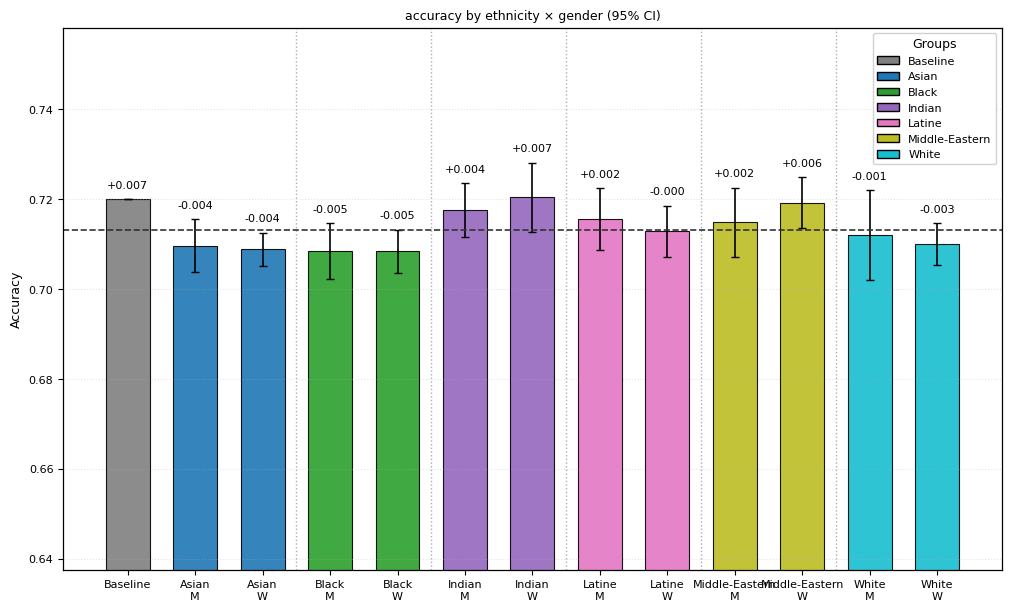

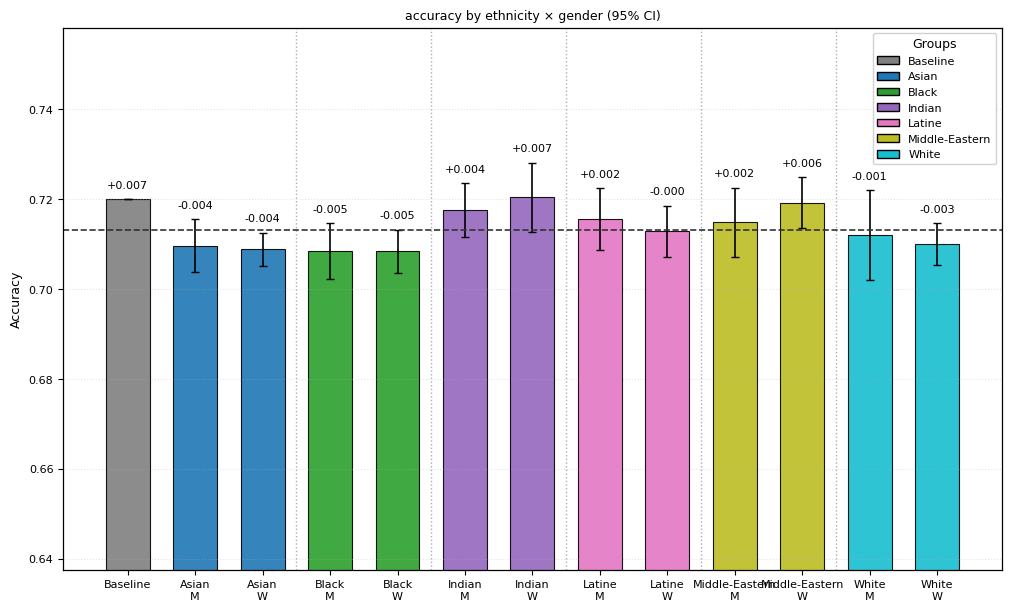

In [126]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS,
                                        plots_root="results/figs",
                                        strategy="zero_shot",
                                        stage="preliminary")

In [127]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, person_set=PERSON_ETHNICS,
                                        plots_root="results/figs",
                                        strategy="zero_shot", 
                                        stage="tier1",
                                        per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 308)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 308)
Found category values in stereotype_type: ['gender', 'profession', 'race', 'religion']

=== RISK–BENEFIT in terms of TOKENS ===

Top profiles by risk-adjusted efficiency (RAE_λ):
  profile57    RAE=0.0001 | rescue=0.113 | extra=0.039 | tok/sample=347.9
  profile48    RAE=0.0001 | rescue=0.122 | extra=0.044 | tok/sample=347.9
  profile32    RAE=0.0001 | rescue=0.112 | extra=0.039 | tok/sample=350.9
  profile46    RAE=0.0001 | rescue=0.115 | extra=0.041 | tok/sample=346.9
  profile60    RAE=0.0001 | rescue=0.110 | extra=0.039 | tok/sample=347.9
  profile52    RAE=0.0001 | rescue=0.108 | extra=0.039 | tok/sample=347.9
  profile59    RAE=0.0001 | rescue=0.126 | extra=0.048 | tok/sample=346.9
  profil

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:690: UserWarning: The figure layout has changed to tight
  # ========================================================================



Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']

Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:765: UserWarning: The figure layout has changed to tight
  



PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 16
  man_indian_25 (profile52)
    Rescue Rate: 0.081, E

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1196: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


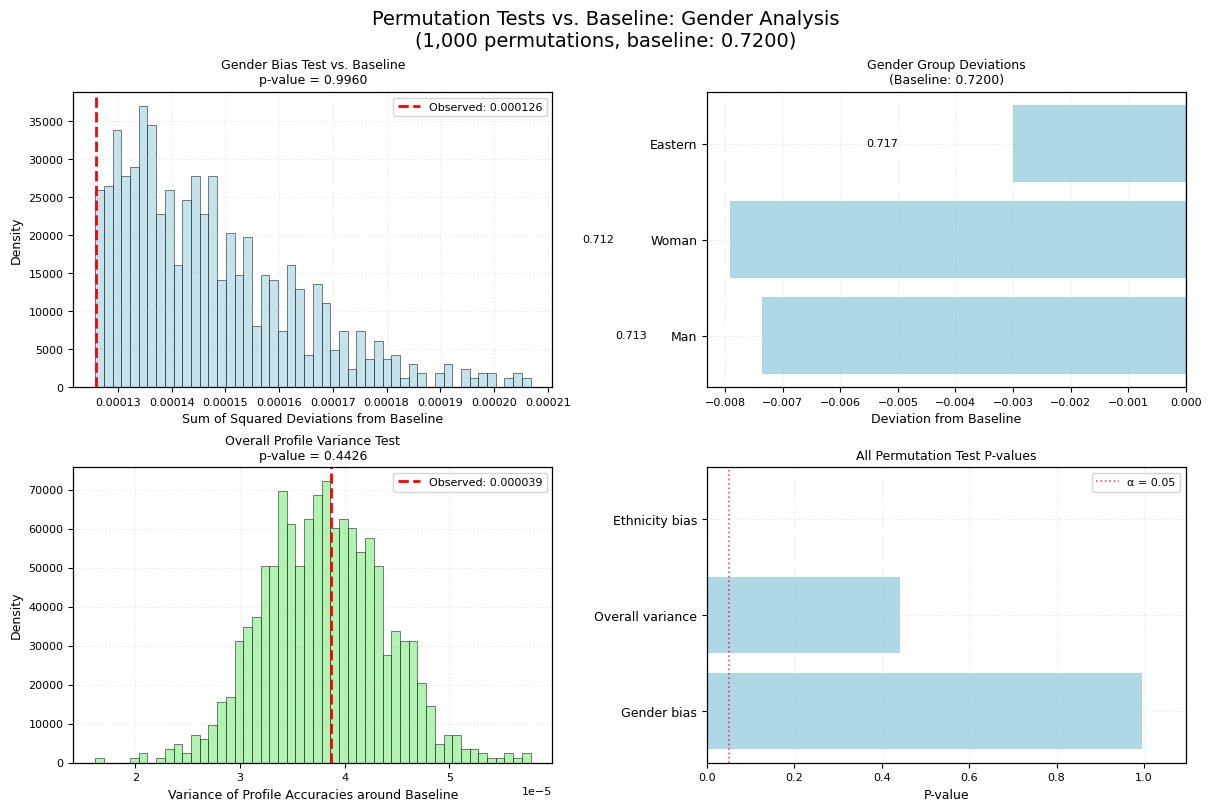

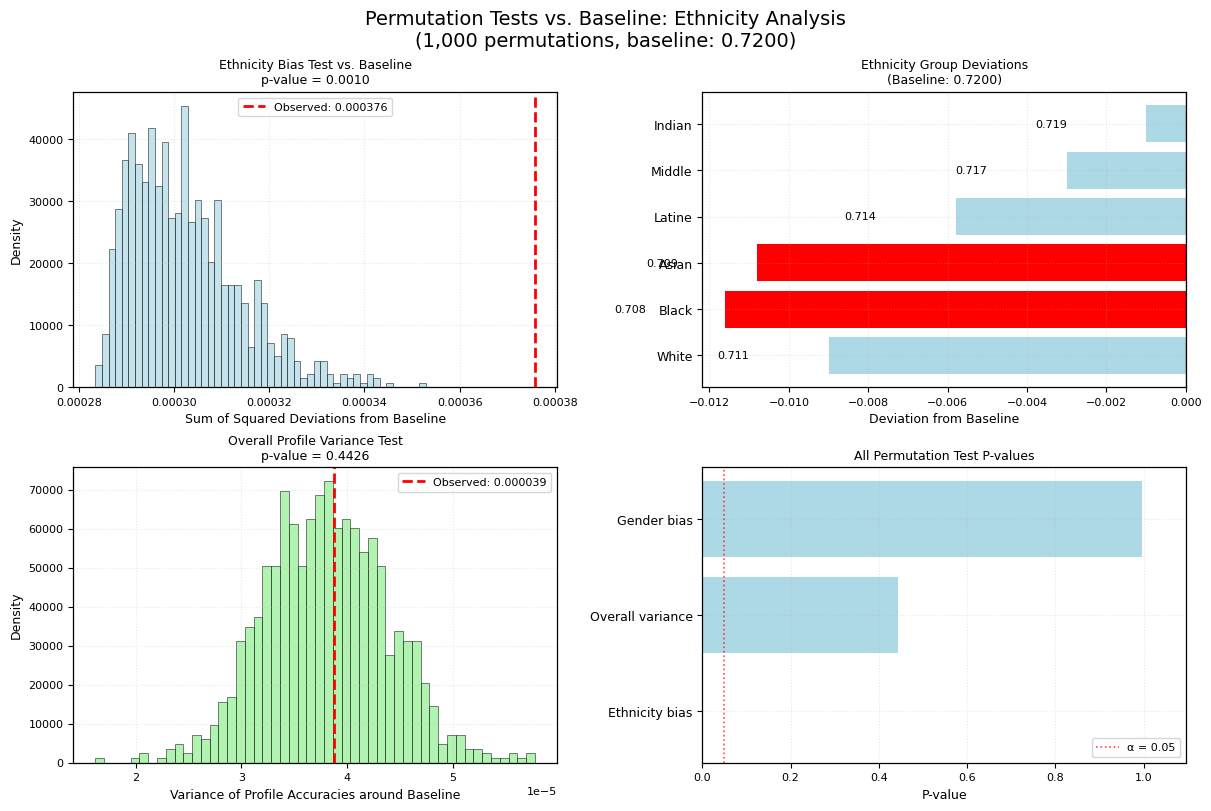

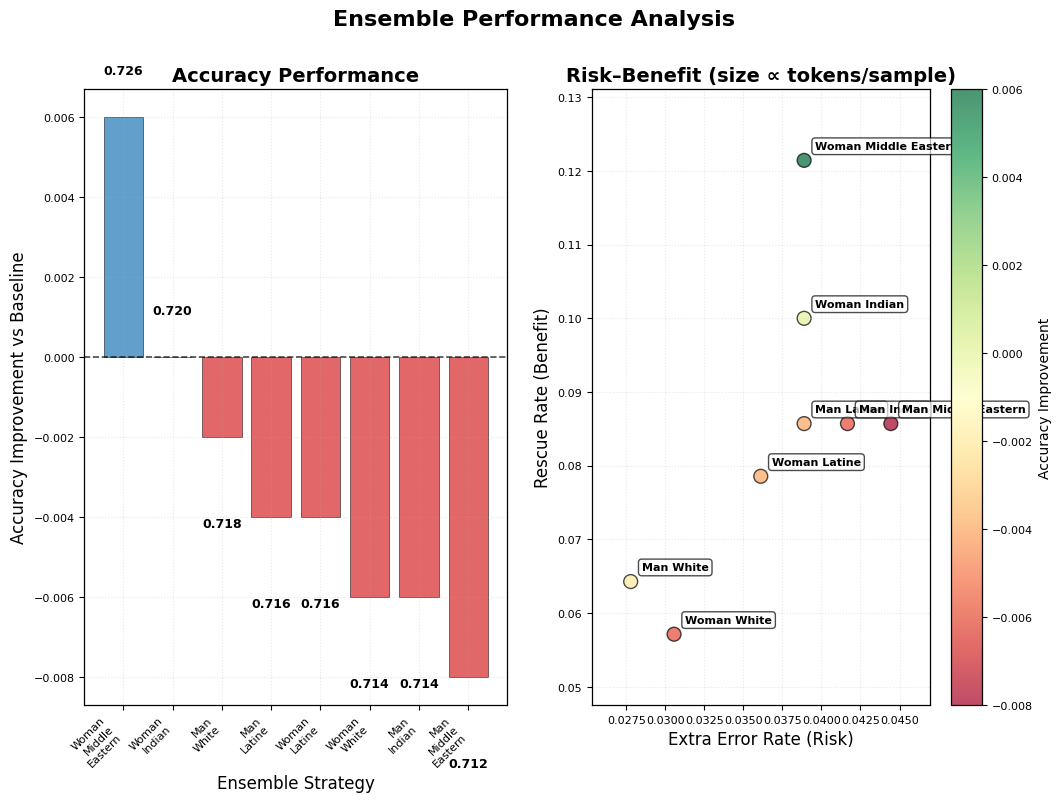

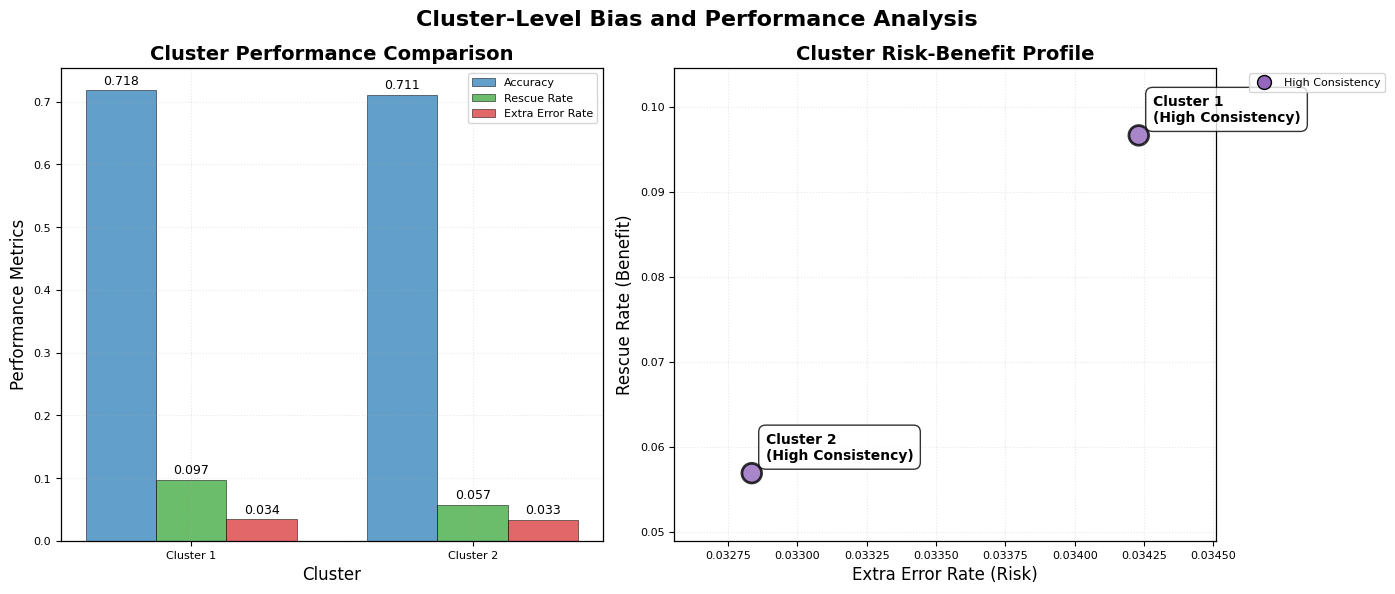

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1406: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


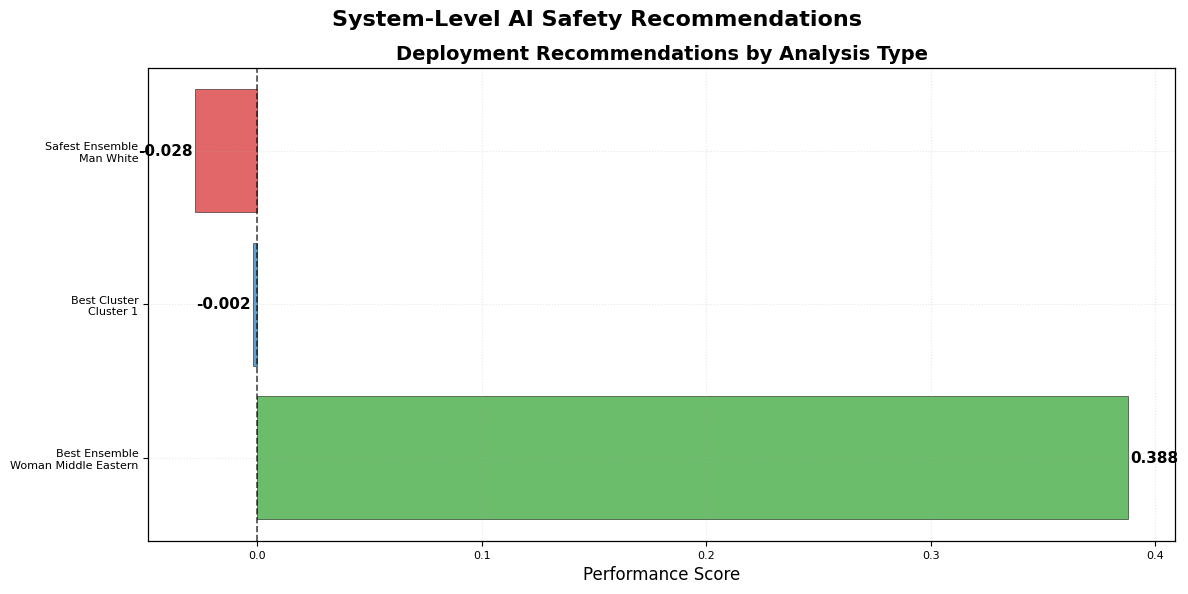


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_middle_eastern
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [128]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="zero_shot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in stereotype_type: ['gender', 'profession', 'race', 'religion']
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 16)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.282, p=0.0289 ***
  Consistency vs Boldness: r=0.283, p=0.0286 ***
  Volatility vs Rescue Rate: r=-0.242, p=0.0619 
  Boldness vs Accuracy: r=0.562, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:477: UserWarning: The figure layout has changed to tight
  
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:488: UserWarning: The figure layout has changed to tight
  
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:527: UserWarning: The figure layout has changed to tight
  figs['archetype_by_demo'] = figC
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:558: UserWarning: The figure layout has changed to tight
  figs['cv_trends'] = figD


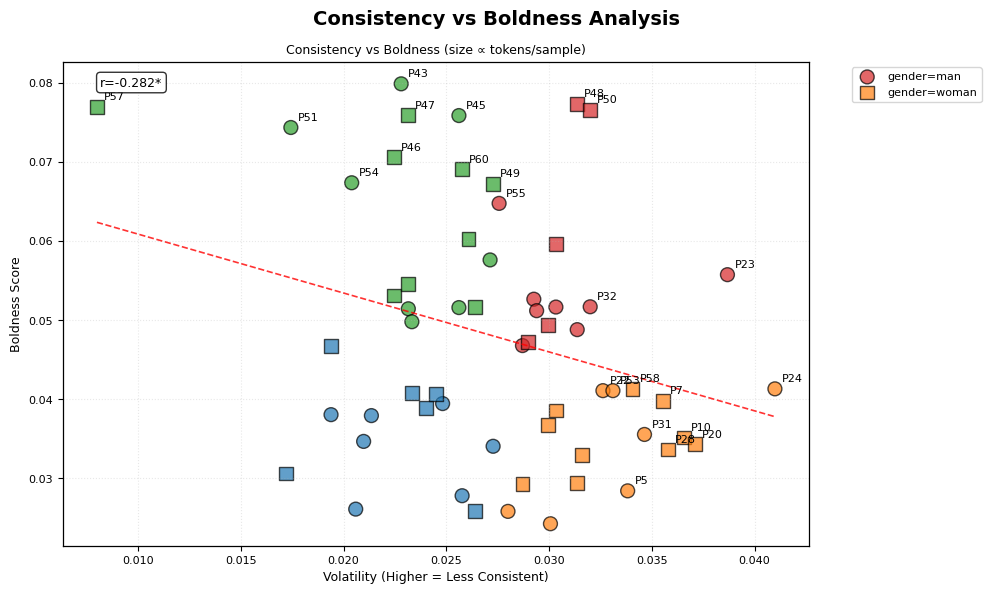

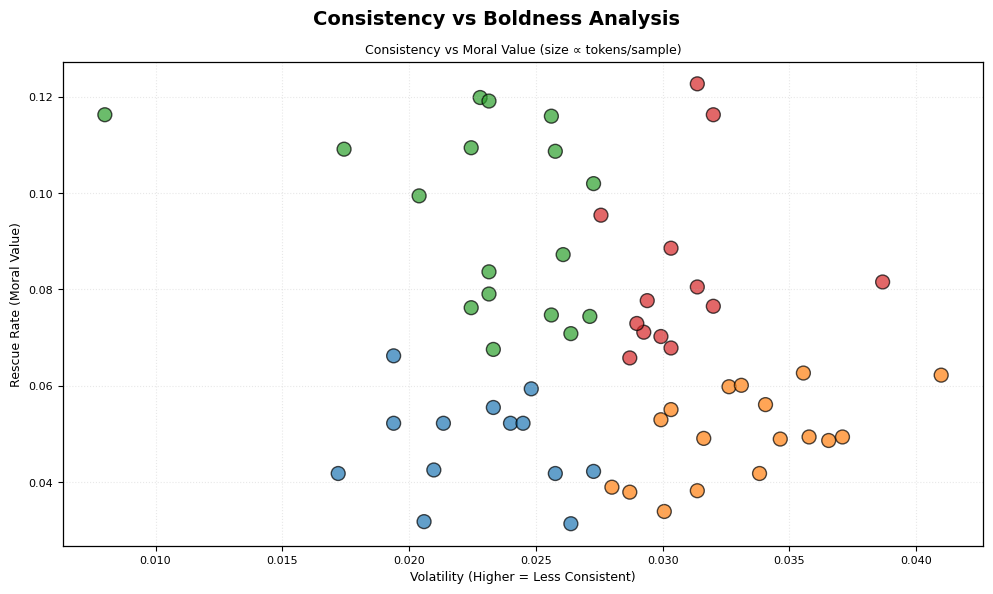

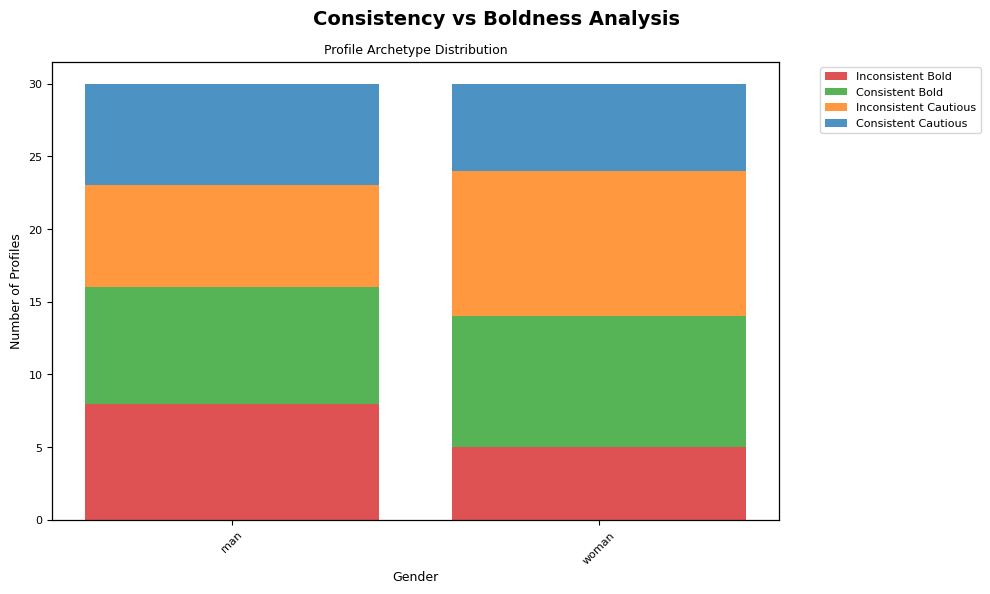

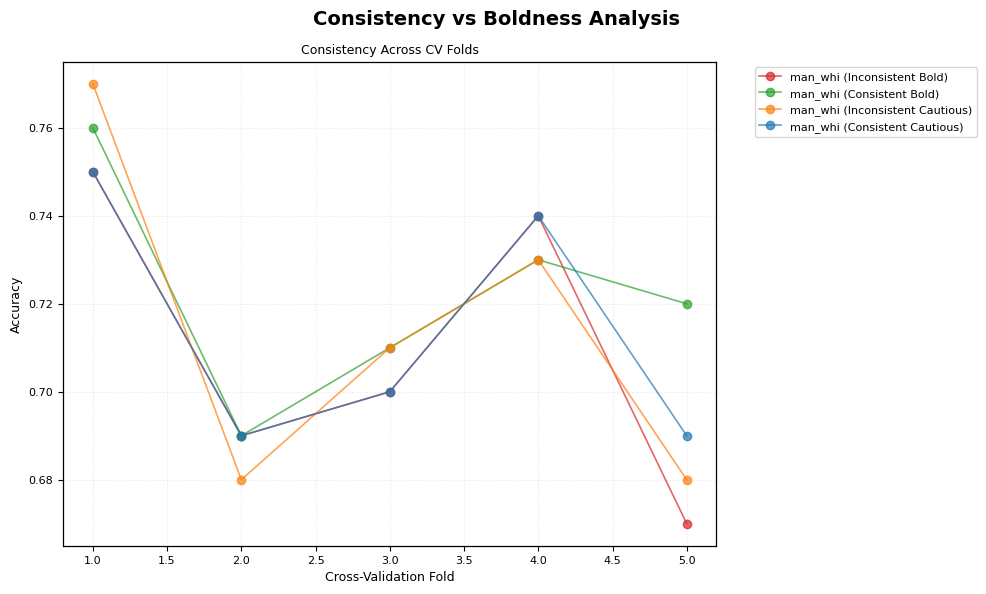

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===
Causal visualizations created successfully


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:477: UserWarning: The figure layout has changed to tight
  
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:488: UserWarning: The figure layout has changed to tight
  
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:527: UserWarning: The figure layout has changed to tight
  figs['archetype_by_demo'] = figC
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:558: UserWarning: The figure layout has changed to tight
  figs['cv_trends'] = figD


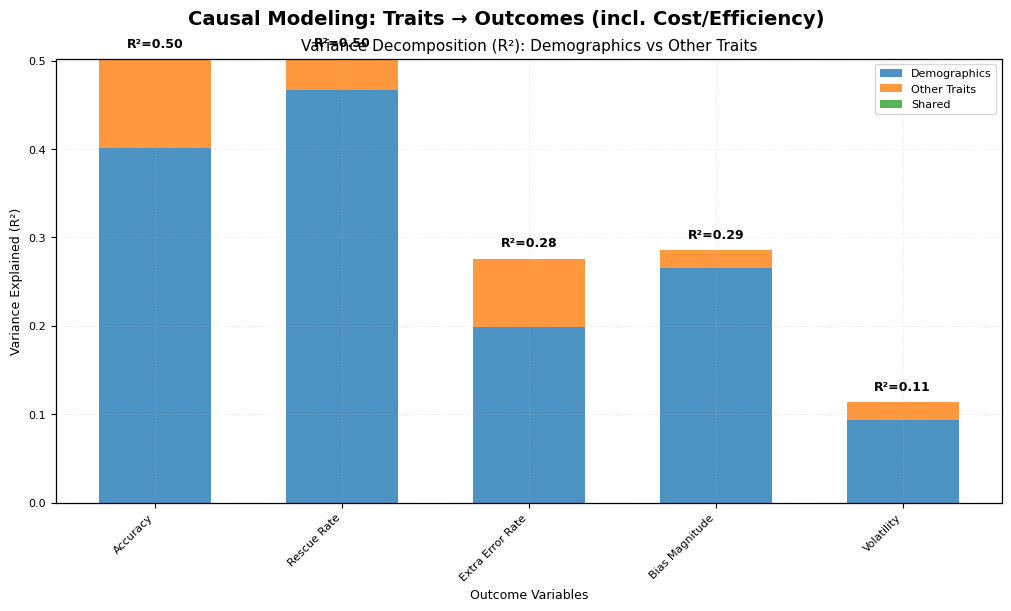

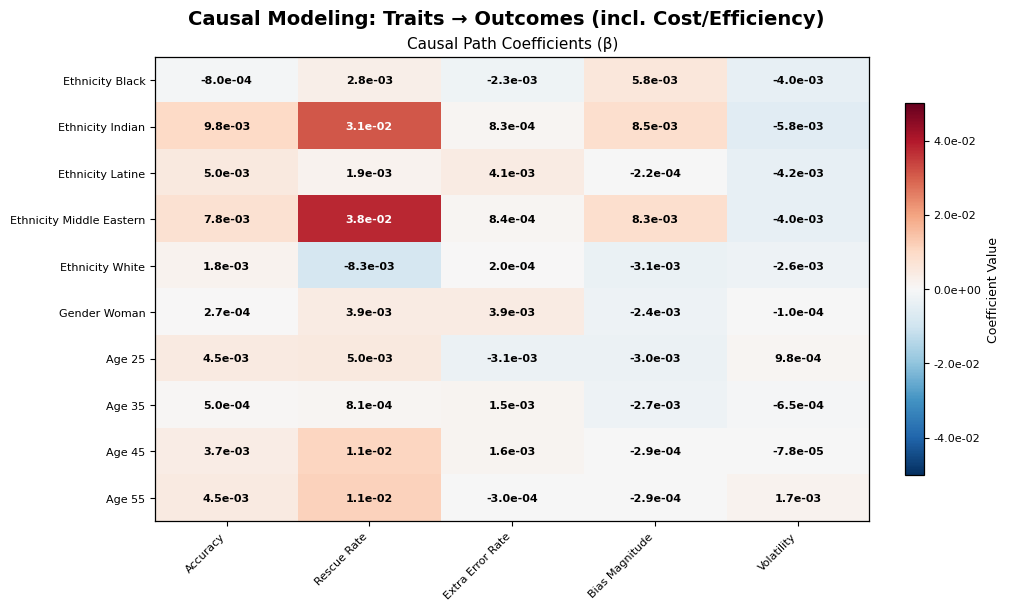

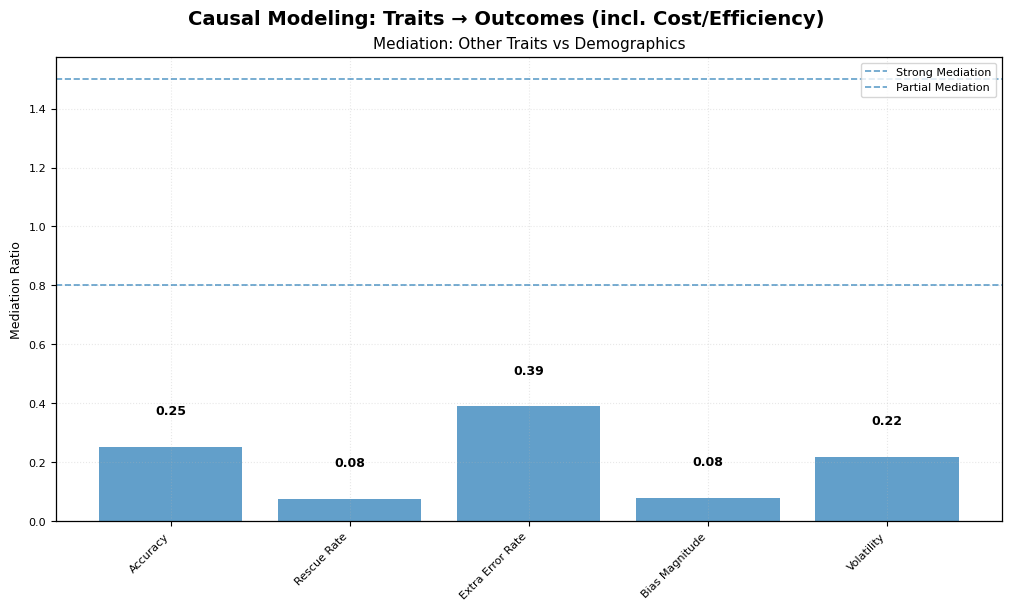

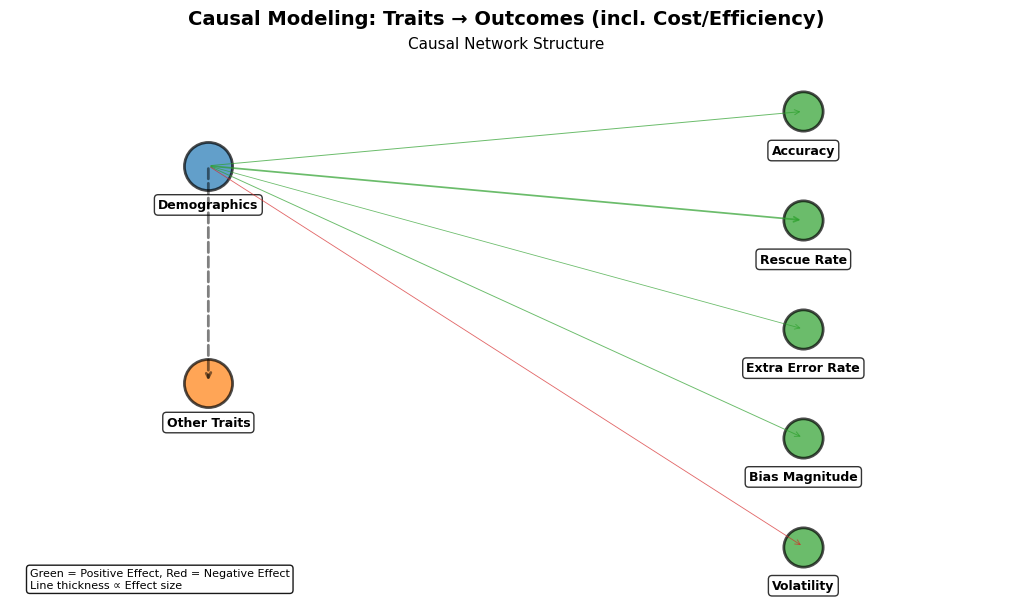

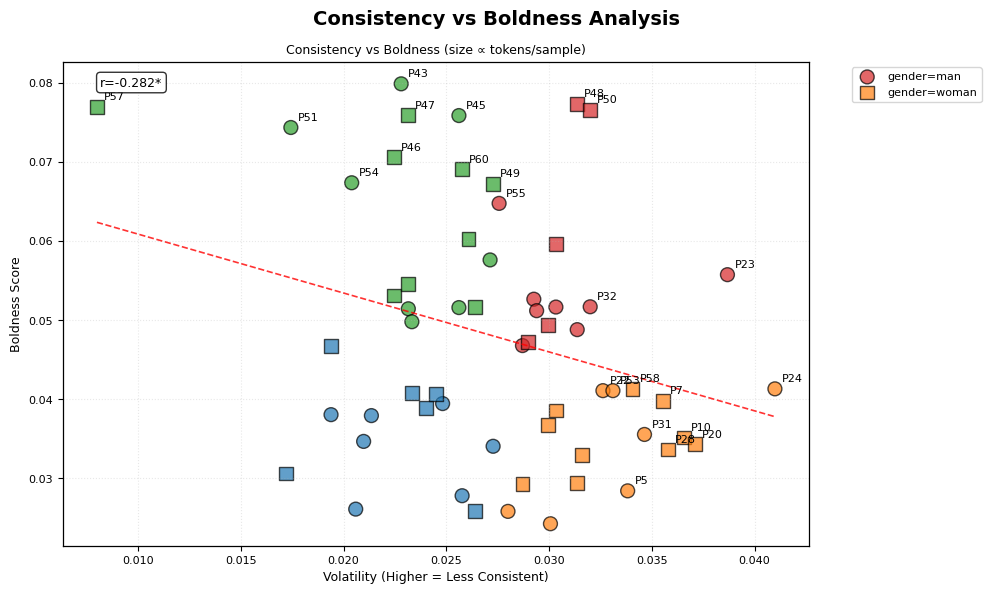

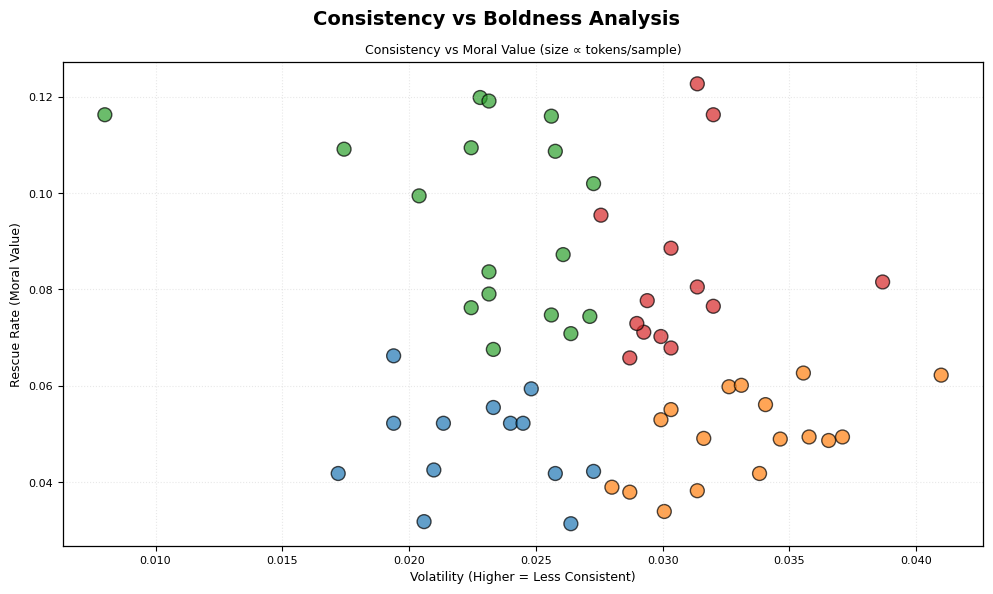

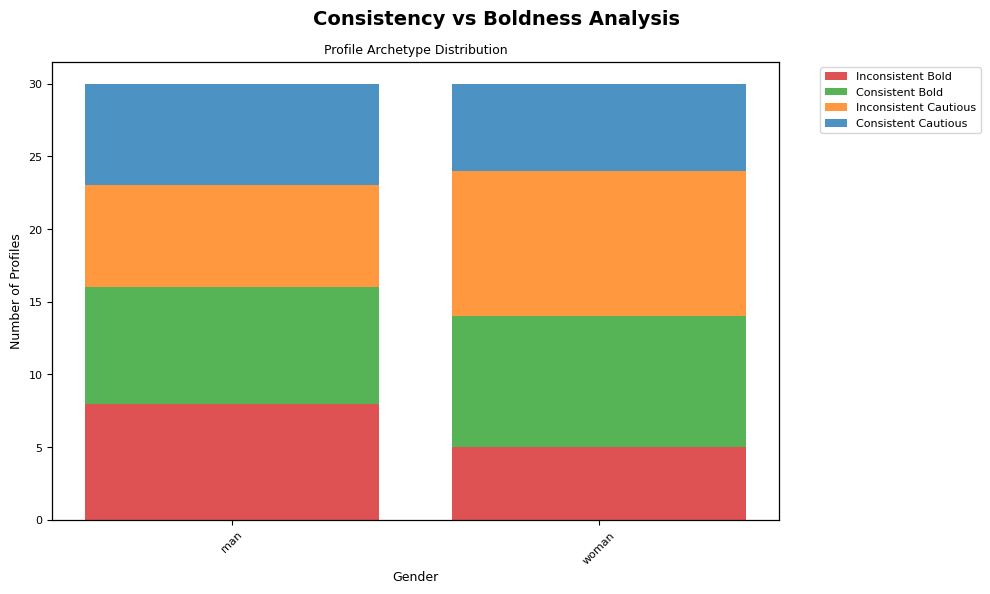

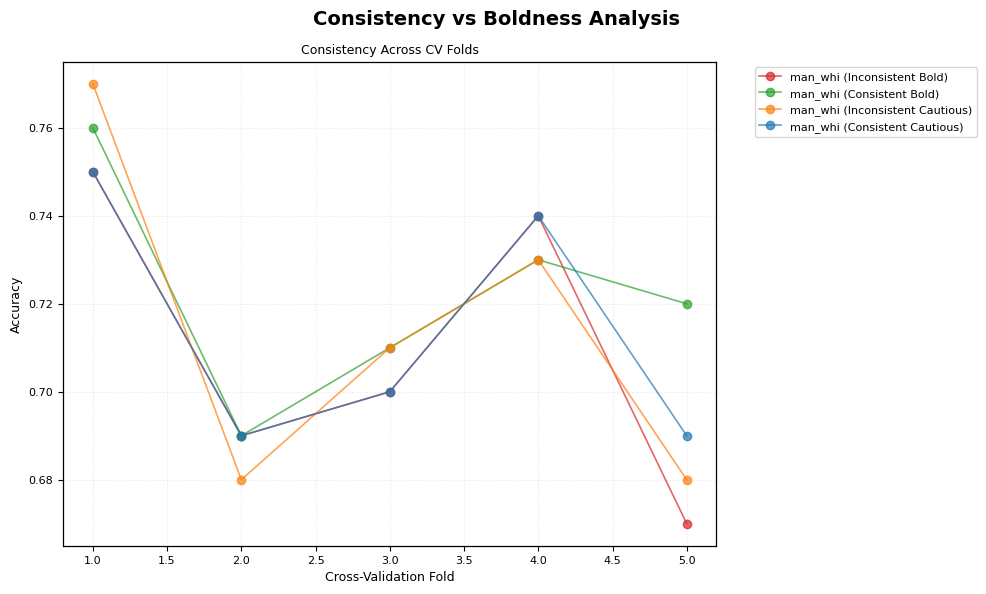


Saved tier3 figures:
  [consistency_boldness] consistency_vs_boldness: results/figs/zero_shot/stereotype/tier3/consistency_boldness/consistency_vs_boldness.pdf
  [consistency_boldness] volatility_vs_rescue: results/figs/zero_shot/stereotype/tier3/consistency_boldness/volatility_vs_rescue.pdf
  [consistency_boldness] archetype_by_demo: results/figs/zero_shot/stereotype/tier3/consistency_boldness/archetype_by_demo.pdf
  [consistency_boldness] cv_trends: results/figs/zero_shot/stereotype/tier3/consistency_boldness/cv_trends.pdf
  [causal] variance_decomposition: results/figs/zero_shot/stereotype/tier3/causal_model/variance_decomposition.pdf
  [causal] coef_heatmap: results/figs/zero_shot/stereotype/tier3/causal_model/coef_heatmap.pdf
  [causal] mediation: results/figs/zero_shot/stereotype/tier3/causal_model/mediation.pdf
  [causal] causal_network: results/figs/zero_shot/stereotype/tier3/causal_model/causal_network.pdf

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consis

In [131]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case,
                                       plots_root="results/figs",
                                        strategy="zero_shot", 
                                        stage="tier3",        
                                        per_figure_subdirs={
                                        "consistency": "consistency",
                                        "causal": "causal_model",
                                        },
                                        save=True)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [ ]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=stereotypes_case,
                                                    df = sample_mgsd, 
                                                    person_set=PERSON_ETHNICS,
                                                    plots_root="results/figs",
                                                    strategy="few_shot",
                                                    stage="preliminary")

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=stereotypes_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS,
                                       plots_root="results/figs",
                                       strategy="few_shot", 
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=stereotypes_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="few_shot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                        case=stereotypes_case,
                                        plots_root="results/figs",
                                        strategy="few_shot", 
                                        stage="tier3",
                                        per_figure_subdirs={
                                        "consistency": "consistency",
                                        "causal": "causal_model",
                                        },
                                        save=True)

# Chain-of-Thoughts

### Analysis results chain-of-thoughts - stereotype detection

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            stage="preliminary")

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=stereotypes_case, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot", 
                                            stage="tier1",
                                            per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})  

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

#perf_df_cot = (result_tier1_cot.get("token_economics") or {}).get("per_profile")

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"),
    #perf_df=perf_df_cot,
    plots_root="results/figs",
    strategy="cot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    }
)


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=stereotypes_case, 
                                            #perf_df=perf_df_cot, 
                                            plots_root="results/figs",
                                            strategy="cot", 
                                            stage="tier3",        
                                            per_figure_subdirs={
                                             "consistency": "consistency",
                                             "causal": "causal_model",
                                            },
                                            save=True)